In [1]:
from pathlib import Path
from ebs_dataset_loader import (
    discover_ebs_samples,
    load_ebs_dataset,
    extract_sensor_cubes,
)
from functions import *

DATASET_ROOT = Path('/home/arbash44/coding/hsi/polymers/EBS_only/EBS12_EBS22')
print(DATASET_ROOT)

/home/arbash44/coding/hsi/polymers/EBS_only/EBS12_EBS22


In [2]:
# Load the full dataset (set load_instance=True if you need SAM instances now)
records = load_ebs_dataset(
    dataset_root=DATASET_ROOT,
    classes=['Styrene', 'PP', 'PA', 'PC', 'mix'],
    load_fenix=True,
    load_fx50=True,
    load_dtree=True,
    load_semantic_mask=True,
    load_instance=True,  # change to True if you need instance masks loaded
    load_rgb = True,
)

print(f'Loaded records: {len(records)}')
print('Keys in one record:', records[0].keys()) 

/opt/conda/lib/python3.8/site-packages/spectral/io/envi.py:175: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loaded records: 13
Keys in one record: dict_keys(['class_name', 'sample_name', 'sample_dir', 'fenix_cube', 'fx50_cube', 'dTree_mask', 'semantic_mask', 'instances', 'rgb_cube'])


In [3]:
# Extract only cubes (this is usually what you pass to models)
fenix_cubes, fenix_labels, fenix_names = extract_sensor_cubes(records, sensor='FENIX')
fx50_cubes, fx50_labels, fx50_names = extract_sensor_cubes(records, sensor='FX50')
RGB_cubes, RGB_labels, RGB_names = extract_sensor_cubes(records, sensor='RGB')

print('FENIX cubes:', len(fenix_cubes))
print('FX50 cubes:', len(fx50_cubes))

if fenix_cubes:
    print('FENIX cube shape example:', fenix_cubes[0].shape, np.max(fenix_cubes[0]))
if fx50_cubes:
    print('FX50 cube shape example:', fx50_cubes[0].shape)
if RGB_cubes:
    print('RGB shape example:', RGB_cubes[0].shape)

FENIX cubes: 13
FX50 cubes: 13
FENIX cube shape example: (640, 1114, 450) 0.8658731
FX50 cube shape example: (640, 1114, 308)
RGB shape example: (3840, 6684, 3)


In [4]:
gt = []
semantic_masks = []
instance_masks = []
for i in range(len(records)):
    print(fenix_names[i])
    print(fx50_names[i])
    gt.append(records[i]["dTree_mask"])
    semantic_masks.append(records[i]["semantic_mask"].astype(bool))
    instance_masks.append(records[i]["instances"])
    print(gt[0].shape,semantic_masks[0].shape)

EBS12_11mm_5mm_Styrole2
EBS12_11mm_5mm_Styrole2
(640, 1114) (640, 1114)
EBS22_SLF_Styrole2
EBS22_SLF_Styrole2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PP2
EBS12_11mm_5mm_PP2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PP2
EBS12_30mm_5mm_PP2
(640, 1114) (640, 1114)
EBS22_SLF_PP2
EBS22_SLF_PP2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PA2
EBS12_11mm_5mm_PA2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PA2
EBS12_30mm_5mm_PA2
(640, 1114) (640, 1114)
EBS22_SLF_PA2
EBS22_SLF_PA2
(640, 1114) (640, 1114)
EBS12_11mm_5mm_PC2
EBS12_11mm_5mm_PC2
(640, 1114) (640, 1114)
EBS12_30mm_5mm_PC2
EBS12_30mm_5mm_PC2
(640, 1114) (640, 1114)
EBS22_SLF_PC2
EBS22_SLF_PC2
(640, 1114) (640, 1114)
1
1
(640, 1114) (640, 1114)
2
2
(640, 1114) (640, 1114)


In [5]:
# Sorting cubes to classes
Styrene_FENIX = fenix_cubes[:2]
Styrene_FX = fx50_cubes[:2]
Styrene_gt = gt[:2]
Styrene_semantic_masks = semantic_masks[:2]
Styrene_instance = instance_masks[:2]
print('Styrene: ', len(Styrene_FX), len(Styrene_gt), len(Styrene_semantic_masks), len(Styrene_instance))

PA_FENIX = fenix_cubes[5:8]
PA_FX = fx50_cubes[5:8]
PA_gt = gt[5:8]
PA_semantic_masks = semantic_masks[5:8]
PA_instance = instance_masks[5:8]
print('PA: ', len(PA_FX), len(PA_gt), len(PA_semantic_masks), len(PA_instance))

PC_FENIX = fenix_cubes[8:11]
PC_FX = fx50_cubes[8:11]
PC_gt = gt[8:11]
PC_semantic_masks = semantic_masks[8:11]
PC_instance = instance_masks[8:11]
print('PC: ', len(PC_FX), len(PC_gt), len(PC_semantic_masks), len(PC_instance))


PP_FENIX = fenix_cubes[2:5]
PP_FX = fx50_cubes[2:5]
PP_gt = gt[2:5]
PP_semantic_masks = semantic_masks[2:5]
PP_instance = instance_masks[2:5]
print('PP: ', len(PP_FX), len(PP_gt), len(PP_semantic_masks), len(PP_instance))

Mix_FENIX = fenix_cubes[11:]
Mix_FX = fx50_cubes[11:]
Mix_gt = gt[11:]
Mix_semantic_masks = semantic_masks[11:]
Mix_instance = instance_masks[11:]
print('Mix: ', len(Mix_FX), len(Mix_gt), len(Mix_semantic_masks), len(Mix_instance))



Styrene:  2 2 2 2
PA:  3 3 3 3
PC:  3 3 3 3
PP:  3 3 3 3
Mix:  2 2 2 2


In [6]:
# Normalizing the cubes
Styrene_FENIX_norm = [snv_normalize(i) for i in Styrene_FENIX]
print("Styrene_FENIX_norm Done !")
Styrene_FX_norm = [snv_normalize(i) for i in Styrene_FX]
print("Styrene_FX_norm Done !")
PP_FENIX_norm = [snv_normalize(i) for i in PP_FENIX]
print("PP_FENIX_norm Done !")
PP_FX_norm = [snv_normalize(i) for i in PP_FX]
print("PP_FX_norm Done !")
PA_FENIX_norm = [snv_normalize(i) for i in PA_FENIX]
print("PA_FENIX_norm Done !")
PA_FX_norm = [snv_normalize(i) for i in PA_FX]
print("PA_FX_norm Done !")
PC_FENIX_norm = [snv_normalize(i) for i in PC_FENIX]
print("PC_FENIX_norm Done !")
PC_FX_norm = [snv_normalize(i) for i in PC_FX]
print("PC_FX_norm Done !")
Mix_FENIX_norm = [snv_normalize(i) for i in Mix_FENIX]
print("Mix_FENIX_norm Done !")
Mix_FX_norm = [snv_normalize(i) for i in Mix_FX]
print("Mix_FX_norm Done !")


Styrene_FENIX_norm Done !
Styrene_FX_norm Done !
PP_FENIX_norm Done !
PP_FX_norm Done !
PA_FENIX_norm Done !
PA_FX_norm Done !
PC_FENIX_norm Done !
PC_FX_norm Done !
Mix_FENIX_norm Done !
Mix_FX_norm Done !


In [7]:
# Slicing and Converting to NumPy Arrays

def select_roi_bands(hsi_list, sensor_type):
    FENIX_SLICES = [
    slice(285, 321),  # 1600 - 1800 nm
    slice(322, 357),  # 1800 - 2000 nm
    slice(358, 394)   # 2000 - 2200 nm
    ]

    FX50_SLICES = [
    slice(32, 38),    # 2976 - 3018 nm
    slice(75, 86),    # 3336 - 3420 nm
    slice(86, 97),    # 3428 - 3512 nm
    slice(114, 119),  # 3663 - 3696 nm
    slice(209, 212)   # 4458 - 4475 nm
    ]

    """Keep only fingerprint bands. sensor_type: 'FENIX' or 'FX50'."""
    sensor_key = sensor_type.upper()
    slice_map = {"FENIX": FENIX_SLICES, "FX50": FX50_SLICES}
    if sensor_key not in slice_map:
        raise ValueError(f"Unknown sensor_type '{sensor_type}'.")
    roi_cubes = []
    for cube in hsi_list:
        np_cube = np.asarray(cube)
        if np_cube.ndim != 3:
            raise ValueError(f"Expected 3D cube; got shape {np_cube.shape}.")
        roi_cube = np.concatenate(
            [np_cube[:, :, band_slice] for band_slice in slice_map[sensor_key]], axis=2
        )
        roi_cubes.append(roi_cube)
    return roi_cubes


# Process B6_SSF data
print("Slicing data...")
Styrene_FENIX_norm_roi = select_roi_bands(Styrene_FENIX_norm, 'FENIX')
print(Styrene_FENIX_norm[0].shape, Styrene_FENIX_norm_roi[0].shape)
Styrene_FX_norm_roi = select_roi_bands(Styrene_FX_norm, 'FX50')
print(Styrene_FX_norm[0].shape, Styrene_FX_norm_roi[0].shape)

PA_FENIX_norm_roi = select_roi_bands(PA_FENIX_norm, 'FENIX')
PA_FX_norm_roi = select_roi_bands(PA_FX_norm, 'FX50')

PC_FENIX_norm_roi = select_roi_bands(PC_FENIX_norm, 'FENIX')
PC_FX_norm_roi = select_roi_bands(PC_FX_norm, 'FX50')

PP_FENIX_norm_roi = select_roi_bands(PP_FENIX_norm, 'FENIX')
PP_FX_norm_roi = select_roi_bands(PP_FX_norm, 'FX50')

Mix_FENIX_norm_roi = select_roi_bands(Mix_FENIX_norm, 'FENIX')
Mix_FX_norm_roi = select_roi_bands(Mix_FX_norm, 'FX50')

Slicing data...
(640, 1114, 450) (640, 1114, 107)
(640, 1114, 308) (640, 1114, 36)


In [8]:
# Concatenating FENIX and FX50
Styrene = concat_hsi_lists(Styrene_FENIX_norm_roi, Styrene_FX_norm_roi)
PA = concat_hsi_lists(PA_FENIX_norm_roi, PA_FX_norm_roi)
PC = concat_hsi_lists(PC_FENIX_norm_roi, PC_FX_norm_roi)
PP = concat_hsi_lists(PP_FENIX_norm_roi, PP_FX_norm_roi)
Mix = concat_hsi_lists(Mix_FENIX_norm_roi, Mix_FX_norm_roi)

print(Styrene[0].shape, PA[0].shape, PC[0].shape, PP[0].shape, Mix[0].shape)

(640, 1114, 143) (640, 1114, 143) (640, 1114, 143) (640, 1114, 143) (640, 1370, 143)


In [9]:
len(Styrene)

2

In [10]:
# Train - Test Split

Styrene_train = [Styrene[1]]
Styrene_train_gt = [Styrene_gt[1]]
Styrene_train_semantic_masks = [Styrene_semantic_masks[1]]
Styrene_train_instance = [Styrene_instance[1]]
PA_train = [PA[1], PA[2]]
PA_train_gt = [PA_gt[1], PA_gt[2]]
PA_train_semantic_masks = [PA_semantic_masks[1], PA_semantic_masks[2]]
PA_train_instance = [PA_instance[1], PA_instance[2]]
PC_train = [PC[1], PC[2]]
PC_train_gt = [PC_gt[1], PC_gt[2]]
PC_train_semantic_masks = [PC_semantic_masks[1], PC_semantic_masks[2]]
PC_train_instance = [PC_instance[1], PC_instance[2]]
PP_train = [PP[1], PP[2]]
PP_train_gt = [PP_gt[1], PP_gt[2]]
PP_train_semantic_masks = [PP_semantic_masks[1], PP_semantic_masks[2]]
PP_train_instance = [PP_instance[1], PP_instance[2]]
Mix_train = [Mix[1]]
Mix_train_gt = [Mix_gt[1]]
Mix_train_semantic_masks = [Mix_semantic_masks[1]]
Mix_train_instance = [Mix_instance[1]]

Styrene_test = [Styrene[0]]
Styrene_test_gt = [Styrene_gt[0]]
Styrene_test_semantic_masks = [Styrene_semantic_masks[0]]
Styrene_test_instance = [Styrene_instance[0]]
PA_test = [PA[0]]
PA_test_gt = [PA_gt[0]]
PA_test_semantic_masks = [PA_semantic_masks[0]]
PA_test_instance = [PA_instance[0]]
PC_test = [PC[0]]
PC_test_gt = [PC_gt[0]]
PC_test_semantic_masks = [PC_semantic_masks[0]]
PC_test_instance = [PC_instance[0]]
PP_test = [PP[0]]
PP_test_gt = [PP_gt[0]]
PP_test_semantic_masks = [PP_semantic_masks[0]]
PP_test_instance = [PP_instance[0]]
Mix_test = [Mix[0]]
Mix_test_gt = [Mix_gt[0]]
Mix_test_semantic_masks = [Mix_semantic_masks[0]]
Mix_test_instance = [Mix_instance[0]]


In [11]:
Training_cubes = Styrene_train + PA_train + PC_train + PP_train + Mix_train
Training_cubes_gt = Styrene_train_gt + PA_train_gt + PC_train_gt + PP_train_gt + Mix_train_gt
Training_cubes_semantic_masks = Styrene_train_semantic_masks + PA_train_semantic_masks + PC_train_semantic_masks + PP_train_semantic_masks + Mix_train_semantic_masks
Training_cubes_instance_masks = Styrene_train_instance + PA_train_instance + PC_train_instance + PP_train_instance + Mix_train_instance
print(len(Training_cubes), len(Training_cubes_gt), len(Training_cubes_semantic_masks), len(Training_cubes_instance_masks))

Test_cubes = Styrene_test + PA_test + PC_test + PP_test + Mix_test
Test_cubes_gt = Styrene_test_gt + PA_test_gt + PC_test_gt + PP_test_gt + Mix_test_gt
Test_cubes_semantic_masks = Styrene_test_semantic_masks + PA_test_semantic_masks + PC_test_semantic_masks + PP_test_semantic_masks + Mix_test_semantic_masks
Test_cubes_instance_masks = Styrene_test_instance + PA_test_instance + PC_test_instance + PP_test_instance + Mix_test_instance
print(len(Test_cubes), len(Test_cubes_gt), len(Test_cubes_semantic_masks), len(Test_cubes_instance_masks))


8 8 8 8
5 5 5 5


In [12]:
np.unique(Styrene_train_gt[0],return_counts = True), np.unique(Mix_train_gt[0],return_counts = True)

((array([0, 1]), array([520302, 196498])),
 (array([0, 1, 2, 3, 4]), array([821055,  17845,  15644,   1615,  21281])))

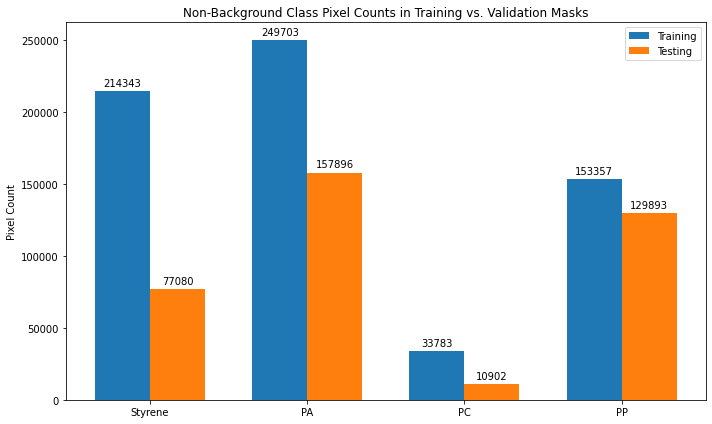

In [13]:
plot_non_background_statistics(Training_cubes_gt, Test_cubes_gt)

## Spectral Angle Mapper (SAM) Workflow

Run the setup cells above first, up to the creation of `Training_cubes`, `Training_cubes_gt`, `Test_cubes`, `Test_cubes_gt`, `Test_cubes_semantic_masks`, and `Test_cubes_instance_masks`.

Reference spectra are the per-class mean spectra from the training set (background label 0 ignored). Each test pixel is assigned the class with the smallest spectral angle to its reference.

In [14]:
# 1) Helper functions: reference spectra, SAM prediction, and evaluation

from sklearn.metrics import confusion_matrix

CLASS_LABELS = [1, 2, 3, 4]
CLASS_NAMES = ['Styrene', 'PA', 'PC', 'PP']
BACKGROUND_LABEL = 0
EVALUATION_LABELS = [BACKGROUND_LABEL] + CLASS_LABELS


def extract_labeled_pixels(cubes, masks, ignore_labels=(BACKGROUND_LABEL,)):
    """Extract spectra and labels from non-background pixels."""
    X_parts = []
    y_parts = []
    valid_masks = []

    for cube, mask in zip(cubes, masks):
        cube = np.asarray(cube)
        mask = np.asarray(mask)

        if cube.shape[:2] != mask.shape:
            raise ValueError(f'Cube and mask shapes do not match: {cube.shape[:2]} vs {mask.shape}')

        valid_mask = ~np.isin(mask, ignore_labels)
        spectra = cube[valid_mask]
        labels = mask[valid_mask]

        finite_spectra = np.isfinite(spectra).all(axis=1)
        X_parts.append(spectra[finite_spectra])
        y_parts.append(labels[finite_spectra])

        final_valid_mask = np.zeros(mask.shape, dtype=bool)
        final_valid_mask[valid_mask] = finite_spectra
        valid_masks.append(final_valid_mask)

    return np.vstack(X_parts), np.concatenate(y_parts), valid_masks


def compute_class_reference_spectra(train_X, train_y, class_labels=CLASS_LABELS):
    """Mean spectrum per class from labeled training pixels."""
    references = {}
    for label in class_labels:
        class_spectra = train_X[train_y == label]
        if class_spectra.size == 0:
            raise ValueError(f'No training pixels found for class {label}.')
        references[label] = class_spectra.mean(axis=0)
    return references


def spectral_angles(spectra, reference_matrix):
    """Spectral angle (radians) between each spectrum and each reference.

    spectra: (n_pixels, n_bands)
    reference_matrix: (n_classes, n_bands)
    returns: (n_pixels, n_classes)
    """
    spectra = np.asarray(spectra, dtype=np.float64)
    reference_matrix = np.asarray(reference_matrix, dtype=np.float64)

    spectra_norm = np.linalg.norm(spectra, axis=1, keepdims=True)
    ref_norm = np.linalg.norm(reference_matrix, axis=1, keepdims=True)
    eps = 1e-10

    cosine = (spectra @ reference_matrix.T) / (spectra_norm * ref_norm.T + eps)
    cosine = np.clip(cosine, -1.0, 1.0)
    return np.arccos(cosine)


def predict_sam_labels(spectra, reference_spectra, class_labels=CLASS_LABELS):
    """Assign each spectrum to the class with the smallest spectral angle."""
    reference_matrix = np.vstack([reference_spectra[label] for label in class_labels])
    angle_idx = np.argmin(spectral_angles(spectra, reference_matrix), axis=1)
    return np.asarray(class_labels, dtype=np.int64)[angle_idx]


def predict_sam_maps(cubes, valid_masks, reference_spectra, class_labels=CLASS_LABELS):
    """Predict labels with SAM and place them back into full-size maps."""
    pred_maps = []
    for cube, valid_mask in zip(cubes, valid_masks):
        cube = np.asarray(cube)
        spectra = cube[valid_mask]
        pred_labels = predict_sam_labels(spectra, reference_spectra, class_labels=class_labels)

        pred_map = np.zeros(cube.shape[:2], dtype=pred_labels.dtype)
        pred_map[valid_mask] = pred_labels
        pred_maps.append(pred_map)
    return pred_maps


def evaluate_maps(gt_maps, pred_maps, labels=EVALUATION_LABELS, class_labels=CLASS_LABELS, ignore_labels=(BACKGROUND_LABEL,)):
    """Evaluate maps on non-background GT pixels while counting background predictions as errors."""
    y_true_parts = []
    y_pred_parts = []

    for gt_map, pred_map in zip(gt_maps, pred_maps):
        gt_map = np.asarray(gt_map)
        pred_map = np.asarray(pred_map)

        if gt_map.shape != pred_map.shape:
            raise ValueError(f'GT and prediction shapes do not match: {gt_map.shape} vs {pred_map.shape}')

        eval_mask = ~np.isin(gt_map, ignore_labels)
        y_true_parts.append(gt_map[eval_mask])
        y_pred_parts.append(pred_map[eval_mask])

    y_true = np.concatenate(y_true_parts)
    y_pred = np.concatenate(y_pred_parts)
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    eps = 1e-10
    label_to_index = {label: index for index, label in enumerate(labels)}
    class_indices = [label_to_index[label] for label in class_labels]

    tp = np.diag(cm)[class_indices]
    fp = cm[:, class_indices].sum(axis=0) - tp
    fn = cm[class_indices, :].sum(axis=1) - tp

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    oa = tp.sum() / (cm.sum() + eps)
    aa = recall.mean()

    return {
        'labels': labels,
        'confusion_matrix': cm,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'iou': iou,
        'OA': oa,
        'AA': aa,
    }


def print_evaluation(title, results):
    print(title)
    print('Labels:', results['labels'])
    print('Confusion Matrix:')
    print(results['confusion_matrix'])
    print('OA:', results['OA'])
    print('AA:', results['AA'])
    print('Precision:', dict(zip(CLASS_NAMES, results['precision'])))
    print('Recall:', dict(zip(CLASS_NAMES, results['recall'])))
    print('F1:', dict(zip(CLASS_NAMES, results['f1_score'])))
    print('IoU:', dict(zip(CLASS_NAMES, results['iou'])))

In [15]:
# 2) Build per-class reference spectra from the training set

train_X, train_y, _ = extract_labeled_pixels(
    Training_cubes,
    Training_cubes_gt,
    ignore_labels=(BACKGROUND_LABEL,),
)

_, test_y, test_valid_masks = extract_labeled_pixels(
    Test_cubes,
    Test_cubes_gt,
    ignore_labels=(BACKGROUND_LABEL,),
)

reference_spectra = compute_class_reference_spectra(train_X, train_y, class_labels=CLASS_LABELS)

print('train_X:', train_X.shape, 'train_y:', train_y.shape)
print('test_y:', test_y.shape)
print('Train labels:', dict(zip(*np.unique(train_y, return_counts=True))))
print('Test labels:', dict(zip(*np.unique(test_y, return_counts=True))))
print('Reference spectra per class:')
for label in CLASS_LABELS:
    ref = reference_spectra[label]
    print(f'  {CLASS_NAMES[label - 1]} ({label}): shape={ref.shape}, norm={np.linalg.norm(ref):.4f}')

train_X: (651186, 143) train_y: (651186,)
test_y: (375771,)
Train labels: {1: 214343, 2: 249703, 3: 33783, 4: 153357}
Test labels: {1: 77080, 2: 157896, 3: 10902, 4: 129893}
Reference spectra per class:
  Styrene (1): shape=(143,), norm=12.1722
  PA (2): shape=(143,), norm=11.6994
  PC (3): shape=(143,), norm=8.9785
  PP (4): shape=(143,), norm=10.7101


In [16]:
# 3) Pixel-wise SAM prediction and evaluation

pixel_pred_maps = predict_sam_maps(
    Test_cubes,
    test_valid_masks,
    reference_spectra,
    class_labels=CLASS_LABELS,
)
pixel_results = evaluate_maps(Test_cubes_gt, pixel_pred_maps)

print_evaluation('Pixel-wise SAM evaluation', pixel_results)

Pixel-wise SAM evaluation
Labels: [0, 1, 2, 3, 4]
Confusion Matrix:
[[     0      0      0      0      0]
 [     0  28302  20392  19613   8773]
 [     0   3902 148381   1995   3618]
 [     0   1399   1828   6718    957]
 [     0   8254  15782   2674 103183]]
OA: 0.7626559793065455
AA: 0.6793755484650116
Precision: {'Styrene': 0.6761593042979652, 'PA': 0.7961080141429204, 'PC': 0.21670967741935415, 'PP': 0.8854553723901787}
Recall: {'Styrene': 0.3671769590036321, 'PA': 0.9397388154228095, 'PC': 0.6162172078517647, 'PP': 0.7943692115818398}
F1: {'Styrene': 0.4759158209352397, 'PA': 0.8619811257233342, 'PC': 0.3206529520878915, 'PP': 0.8374427814973983}
IoU: {'Styrene': 0.312263474375241, 'PA': 0.7574400963766855, 'PC': 0.1909390632105497, 'PP': 0.7203454318246866}


Sample index: 1
Ground truth labels: (array([0, 2]), array([586315, 126645]))
Prediction labels: (array([0, 1, 2, 3, 4]), array([586315,   1694, 123933,    786,    232]))


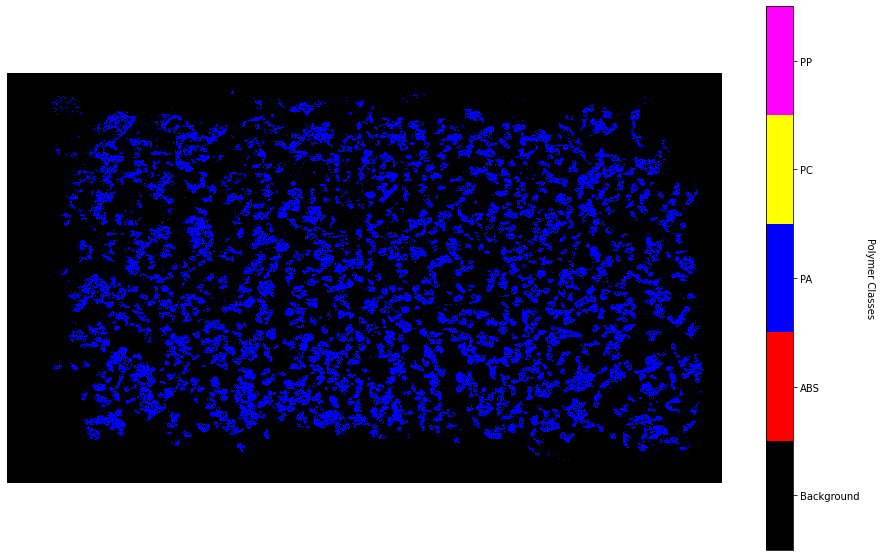

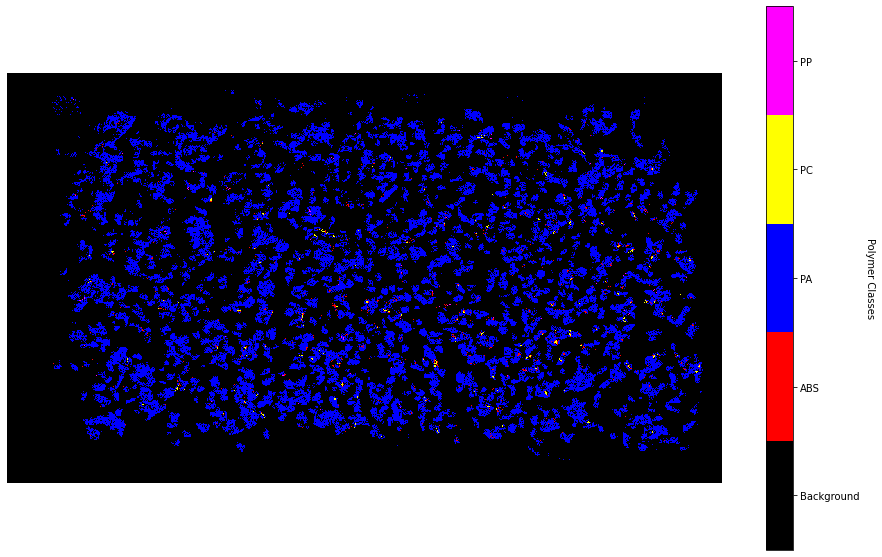

In [17]:
# 4) Optional: visualize one pixel-wise prediction map

sample_idx = 1
print('Sample index:', sample_idx)
print('Ground truth labels:', np.unique(Test_cubes_gt[sample_idx], return_counts=True))
print('Prediction labels:', np.unique(pixel_pred_maps[sample_idx], return_counts=True))

visualize_mask(Test_cubes_gt[sample_idx])
visualize_mask(pixel_pred_maps[sample_idx])

Semantic-object majority voting evaluation
Labels: [0, 1, 2, 3, 4]
Confusion Matrix:
[[     0      0      0      0      0]
 [     0  69668  40948  37340  15330]
 [     0   2317 214209    293    688]
 [     0   9657  29188  85572   5325]
 [     0   3542  18019    828 244028]]
OA: 0.7895944665822341
AA: 0.7467543442944856
Precision: {'Styrene': 0.8178531179564228, 'PA': 0.7084474342183591, 'PC': 0.6899131682697341, 'PP': 0.9195729751932197}
Recall: {'Styrene': 0.42666242053819653, 'PA': 0.9848372696051158, 'PC': 0.6595551170785091, 'PP': 0.915962569956121}
F1: {'Styrene': 0.5607759487616367, 'PA': 0.8240852057042974, 'PC': 0.6743926706228649, 'PP': 0.9177642217827603}
IoU: {'Styrene': 0.38963769980201546, 'PA': 0.7008035019073353, 'PC': 0.5087424124421084, 'PP': 0.8480261328885179}


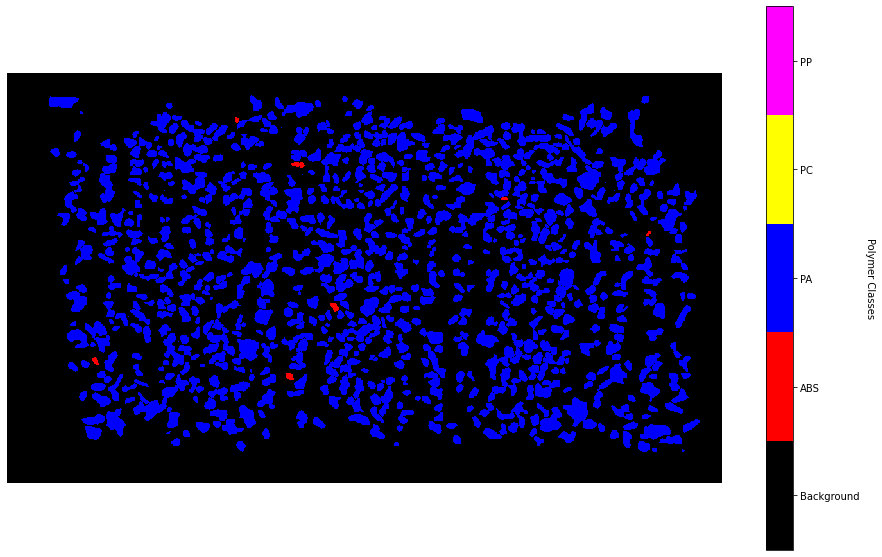

In [18]:
# 5) Semantic-segmentation majority voting on pixel-wise prediction maps

semantic_majority_maps = [
    majority_vote_semantic_objects(pred_map, semantic_mask, ignore_labels=(BACKGROUND_LABEL,))
    for pred_map, semantic_mask in zip(pixel_pred_maps, Test_cubes_semantic_masks)
]

gt_semantic_majority_maps = [
    majority_vote_semantic_objects(pred_map, semantic_mask, ignore_labels=(BACKGROUND_LABEL,))
    for pred_map, semantic_mask in zip(Test_cubes_gt, Test_cubes_semantic_masks)
]

semantic_results = evaluate_maps(gt_semantic_majority_maps, semantic_majority_maps)
print_evaluation('Semantic-object majority voting evaluation', semantic_results)

visualize_mask(semantic_majority_maps[sample_idx])

SAM-instance majority voting evaluation
Labels: [0, 1, 2, 3, 4]
Confusion Matrix:
[[     0      0      0      0      0]
 [     0  67188  40803  41957  14258]
 [     0   1545 211827    355   1459]
 [     0  11860  30424  70405   6144]
 [     0   6599  17314   1185 231334]]
OA: 0.769560210797753
AA: 0.7220388559829076
Precision: {'Styrene': 0.7705752821359749, 'PA': 0.7052249240931122, 'PC': 0.6181190848273072, 'PP': 0.9136594324532472}
Recall: {'Styrene': 0.40916897068316604, 'PA': 0.9843902484362361, 'PC': 0.5924701051054837, 'PP': 0.9021260997067445}
F1: {'Styrene': 0.5345149921185117, 'PA': 0.8217451517686329, 'PC': 0.6050228800497061, 'PP': 0.9078561378704809}
IoU: {'Styrene': 0.36473589924542626, 'PA': 0.697425648691094, 'PC': 0.433715271360808, 'PP': 0.8312605778801475}


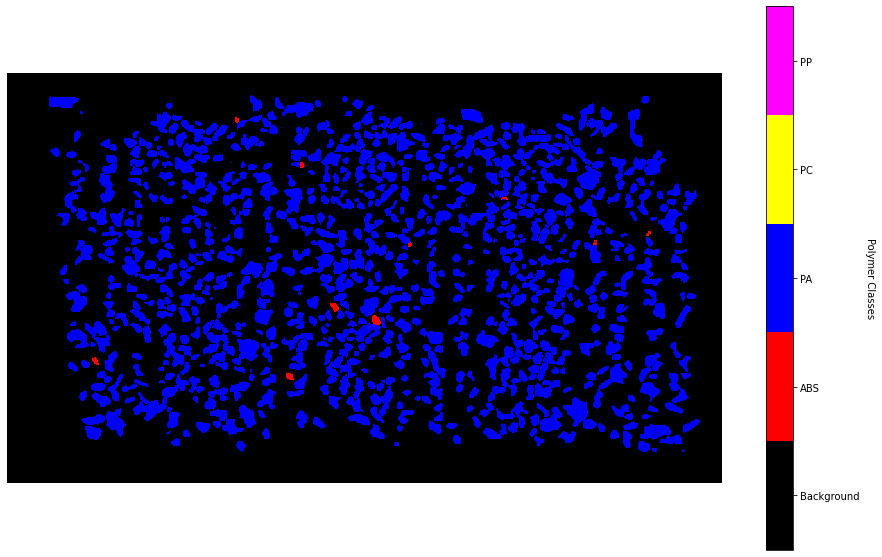

In [19]:
# 6) SAM-instance majority voting on pixel-wise prediction maps

sam_instance_majority_maps = [
    majority_vote_sam_instances(
        pred_map,
        instances,
        ignore_labels=(BACKGROUND_LABEL,),
        overwrite_overlaps=False,
    )
    for pred_map, instances in zip(pixel_pred_maps, Test_cubes_instance_masks)
]

gt_sam_instance_majority_maps = [
    majority_vote_sam_instances(
        pred_map,
        instances,
        ignore_labels=(BACKGROUND_LABEL,),
        overwrite_overlaps=False,
    )
    for pred_map, instances in zip(Test_cubes_gt, Test_cubes_instance_masks)
]

sam_instance_results = evaluate_maps(gt_sam_instance_majority_maps, sam_instance_majority_maps)
print_evaluation('SAM-instance majority voting evaluation', sam_instance_results)

visualize_mask(sam_instance_majority_maps[sample_idx])

In [20]:
# 7) Quick comparison of the three evaluation stages

summary = {
    'Pixel-wise SAM': pixel_results,
    'Semantic majority': semantic_results,
    'SAM-instance majority': sam_instance_results,
}

for name, result in summary.items():
    f1_score = result['f1_score']
    if hasattr(f1_score, 'item') and f1_score.shape == ():
        f1_score = f1_score.item()
    elif hasattr(f1_score, '__len__') and not isinstance(f1_score, str):
        f1_score = float(np.mean(f1_score))

    print(f"{name}: OA={result['OA']:.4f}, AA={result['AA']:.4f}, f1_score={f1_score:.4f}")

Pixel-wise SAM: OA=0.7627, AA=0.6794, f1_score=0.6240
Semantic majority: OA=0.7896, AA=0.7468, f1_score=0.7443
SAM-instance majority: OA=0.7696, AA=0.7220, f1_score=0.7173
